## Project Data Science Lab 2 

In [2]:
import pandas as pd
import re
import os
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
import numpy as np
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Preprocessing

In [3]:
# Load the stopwords
stop_words = set(stopwords.words('english'))

# Function to preprocess the text without using NLTK
def preprocess_text(text):
    # Remove newline characters and replace with a space
    text = text.replace('\n', ' ').replace('\r', ' ')
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\d', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize the text (split by spaces)
    words = text.split()
    # Remove stopwords using the custom stopwords list
    words = [word for word in words if word not in stop_words]
    return words

In [4]:
# Apply preprocessing to the course details
file_path = '../annotated_course_details.xlsx'
df_courses = pd.read_excel(file_path)
# df['preprocessed_course_detail'] = df['course detail description'].apply(preprocess_text)
# df.head()
df_courses['preprocessed_course_detail'] = df_courses['course detail description'].apply(preprocess_text)
df_courses['preprocessed_task_phrases'] = df_courses['task_phrases'].apply(preprocess_text)
df_courses['preprocessed_skill_phrases'] = df_courses['skill_phrases'].apply(preprocess_text)
# df
# Combine annotated phrases with preprocessed course details
df_courses['combined_text_courses'] = (
    df_courses['preprocessed_course_detail'].apply(lambda x: " ".join(x)) + " " + 
    df_courses['preprocessed_task_phrases'].apply(lambda x: " ".join(x)) + " " + 
    df_courses['preprocessed_skill_phrases'].apply(lambda x: " ".join(x)))

In [5]:
# Load the skill roles dataset
df_skill_roles = pd.read_excel('../annotated_skill_roles.xlsx')

# Apply preprocessing to the mission, main tasks, and key skills columns
df_skill_roles['preprocessed_mission'] = df_skill_roles['mission'].apply(preprocess_text)
df_skill_roles['preprocessed_main_tasks'] = df_skill_roles['main_tasks'].apply(preprocess_text)
df_skill_roles['preprocessed_key_skills'] = df_skill_roles['key_skills'].apply(preprocess_text)
df_skill_roles['preprocessed_task_phrases'] = df_skill_roles['unique_task_phrases'].apply(preprocess_text)
df_skill_roles['preprocessed_skill_phrases'] = df_skill_roles['unique_skill_phrases'].apply(preprocess_text)

# Combine the preprocessed text and annotated phrases into a single column
df_skill_roles['combined_text_skill_roles'] = (
    df_skill_roles['preprocessed_mission'].apply(lambda x: " ".join(x)) + " " +
    df_skill_roles['preprocessed_main_tasks'].apply(lambda x: " ".join(x)) + " " +
    df_skill_roles['preprocessed_key_skills'].apply(lambda x: " ".join(x)) + " " +
    df_skill_roles['preprocessed_task_phrases'].apply(lambda x: " ".join(x)) + " " +
    df_skill_roles['preprocessed_skill_phrases'].apply(lambda x: " ".join(x))
)

In [6]:
import pandas as pd
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import time

# Load your datasets
# Extract the combined preprocessed text
courses_text = df_courses['combined_text_courses'].tolist()
skill_roles_text = df_skill_roles['combined_text_skill_roles'].tolist()

# Tag the documents (necessary for Doc2Vec)
tagged_courses = [TaggedDocument(words=text.split(), tags=[f'COURSE_{i}']) for i, text in enumerate(courses_text)]
tagged_skill_roles = [TaggedDocument(words=text.split(), tags=[f'SKILL_ROLE_{i}']) for i, text in enumerate(skill_roles_text)]
tagged_documents = tagged_courses + tagged_skill_roles

# Hyperparameter configurations to test
configs = [
    {"vector_size": 50, "window": 7, "epochs": 30, "dm": 0},
    {"vector_size": 50, "window": 10, "epochs": 30, "dm": 0},
    {"vector_size": 50, "window": 15, "epochs": 30, "dm": 0},
    {"vector_size": 50, "window": 20, "epochs": 30, "dm": 0},
    {"vector_size": 300, "window": 7, "epochs": 30, "dm": 0},
    {"vector_size": 300, "window": 10, "epochs": 30, "dm": 0},
    {"vector_size": 300, "window": 15, "epochs": 30, "dm": 0},
    {"vector_size": 300, "window": 20, "epochs": 30, "dm": 0},
]

# Store results
results = []

for config in configs:
    start_time = time.time()
    
    # Initialize the Doc2Vec model with the current configuration
    model = Doc2Vec(
        vector_size=config["vector_size"],
        window=config["window"],
        min_count=2,
        workers=4,
        epochs=config["epochs"],
        dm=config["dm"]
    )

    # Build the vocabulary and train the model
    model.build_vocab(tagged_documents)
    model.train(tagged_documents, total_examples=model.corpus_count, epochs=model.epochs)
    
    # Extract vectors for courses and skill roles
    course_vectors = [model.dv[f'COURSE_{i}'] for i in range(len(courses_text))]
    skill_role_vectors = [model.dv[f'SKILL_ROLE_{i}'] for i in range(len(skill_roles_text))]
    
    # Calculate the cosine similarity between each course and each skill role
    similarity_matrix = cosine_similarity(course_vectors, skill_role_vectors)
    
    # Calculate metrics
    avg_similarity = similarity_matrix.mean()
    max_similarity = similarity_matrix.max()  # Get the highest similarity value
    negative_scores_percentage = (similarity_matrix < 0).mean() * 100
    training_time = time.time() - start_time
    
    # Store results
    results.append({
        "Vector Size": config["vector_size"],
        "Window": config["window"],
        "Epochs": config["epochs"],
        "Distributed Memory": "Yes" if config["dm"] == 1 else "No",
        "Mean Similarity": avg_similarity,
        "Highest Similarity": max_similarity,
        "Negative Scores (%)": negative_scores_percentage,
        "Training Time (s)": training_time
    })

# Convert the results to a DataFrame for easier analysis
results_df = pd.DataFrame(results)

# Display the results
results_df

# Save the results to an Excel file
results_df.to_excel('doc2vec_hyperparameter_comparison.xlsx', index=False)


In [7]:
results_df

,Vector Size,Window,Epochs,Distributed Memory,Mean Similarity,Highest Similarity,Negative Scores (%),Training Time (s)
0,50,7,30,No,0.318726,0.813014,0.192482,3.220001
1,50,10,30,No,0.319070,0.814363,0.169837,2.981996
2,50,15,30,No,0.316289,0.798684,0.203804,2.749003
3,50,20,30,No,0.317442,0.795287,0.169837,2.871002
4,300,7,30,No,0.315783,0.819315,0.147192,3.728999
5,300,10,30,No,0.315413,0.819287,0.124547,3.660001
6,300,15,30,No,0.316259,0.815506,0.113225,3.944996
7,300,20,30,No,0.315759,0.817319,0.090580,3.834001


In [49]:
# Load your datasets
# Assuming df_courses and df_skill_roles contain the relevant titles and text
courses_text = df_courses['combined_text_courses'].tolist()
course_titles = df_courses['course title'].tolist()  
skill_roles_text = df_skill_roles['combined_text_skill_roles'].tolist()
skill_role_names = df_skill_roles['profile_title'].tolist() 

# Tag the documents (necessary for Doc2Vec)
tagged_courses = [TaggedDocument(words=text.split(), tags=[f'COURSE_{i}']) for i, text in enumerate(courses_text)]
tagged_skill_roles = [TaggedDocument(words=text.split(), tags=[f'SKILL_ROLE_{i}']) for i, text in enumerate(skill_roles_text)]
tagged_documents = tagged_courses + tagged_skill_roles

# Hyperparameter configuration (you can adjust this or iterate through multiple configurations as before)
config = {"vector_size": 300, "window": 20, "epochs": 30, "dm": 0}

# Initialize the Doc2Vec model with the current configuration
model = Doc2Vec(
    vector_size=config["vector_size"],
    window=config["window"],
    min_count=2,
    workers=4,
    epochs=config["epochs"],
    dm=config["dm"]
)

# Build the vocabulary and train the model
model.build_vocab(tagged_documents)
model.train(tagged_documents, total_examples=model.corpus_count, epochs=model.epochs)

# Extract vectors for courses and skill roles
course_vectors = [model.dv[f'COURSE_{i}'] for i in range(len(courses_text))]
skill_role_vectors = [model.dv[f'SKILL_ROLE_{i}'] for i in range(len(skill_roles_text))]

# Calculate the cosine similarity between each course and each skill role
similarity_matrix = cosine_similarity(course_vectors, skill_role_vectors)

# Create a DataFrame to store the similarity scores, with course titles and skill role names as the index and columns
similarity_df = pd.DataFrame(
    similarity_matrix,
    # index=course_titles,  # Use course titles as the index
    columns=skill_role_names  # Use skill role names as the columns
)

# Display the DataFrame
similarity_df

# Add the course titles as a separate column for clarity
similarity_df['Course Title'] = course_titles

# Move 'Course Title' to the front of the DataFrame
similarity_df = similarity_df[['Course Title'] + similarity_df.columns[:-1].tolist()]

# Save the DataFrame to an Excel file
similarity_df.to_excel('course_skill_role_similarity_scores.xlsx')


In [50]:
# Define thresholds for relevance
relevance_threshold = 0.50
potential_threshold = 0.40

# Create a DataFrame for the similarity scores
similarity_df = pd.DataFrame(
    similarity_matrix,
    # index=course_titles,  # Use course titles as the index
    columns=skill_role_names  # Use skill role names as the columns
)

# Convert similarity scores to 'Relevant', 'Potentially Relevant', or 'Not Relevant'
def categorize_similarity(score):
    if score > relevance_threshold:
        return "Relevant"
    elif score > potential_threshold:
        return "Potentially Relevant"
    else:
        return "Not Relevant"

# Apply the categorization function to the similarity matrix
categorized_df = similarity_df.applymap(categorize_similarity)

# Add the course titles as a separate column for clarity
categorized_df['Course Title'] = course_titles

# Move 'Course Title' to the front of the DataFrame
categorized_df = categorized_df[['Course Title'] + categorized_df.columns[:-1].tolist()]

# Display the DataFrame
categorized_df


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14500\4125020828.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  categorized_df = similarity_df.applymap(categorize_similarity)


,Course Title,Chief Information Security Officer (CISO),Cyber Incident Responder,"Cyber Legal, Policy & Compliance Officer",Cyber Threat Intelligence Specialist,Cybersecurity Architect,Cybersecurity Auditor,Cybersecurity Educator,Cybersecurity Implementer,Cybersecurity Researcher,Cybersecurity Risk Manager,Digital Forensics Investigator,Penetration Tester
0,Introduction to Data Science Tools,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant
1,Research Methods and Scientific Ethics,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant
2,Cyber Security Basics,Not Relevant,Relevant,Potentially Relevant,Not Relevant,Potentially Relevant,Not Relevant,Potentially Relevant,Relevant,Potentially Relevant,Potentially Relevant,Not Relevant,Not Relevant
3,Computer Networks and Security,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant
4,Operating Systems and System Programming,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant
...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,Digital Forensics,Not Relevant,Potentially Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Not Relevant,Relevant,Not Relevant
732,Security Audit in Digital Systems and Networks,Potentially Relevant,Relevant,Potentially Relevant,Potentially Relevant,Not Relevant,Relevant,Not Relevant,Potentially Relevant,Potentially Relevant,Potentially Relevant,Relevant,Relevant
733,Software and Application Security,Not Relevant,Potentially Relevant,Potentially Relevant,Not Relevant,Potentially Relevant,Potentially Relevant,Not Relevant,Relevant,Not Relevant,Potentially Relevant,Not Relevant,Potentially Relevant
734,Security Operations and Incident Management,Relevant,Relevant,Potentially Relevant,Relevant,Not Relevant,Relevant,Potentially Relevant,Potentially Relevant,Not Relevant,Relevant,Relevant,Not Relevant


In [10]:
# Initialize a list to store the relevant courses and their top skill profiles
relevant_courses = []

# Iterate over each row in categorized_df using the integer index
for index, row in categorized_df.iterrows():
    course_title = row['Course Title']
    
    # Collect relevant and potentially relevant skill profiles
    relevant_skills = []
    for skill_profile in similarity_df.columns:
        if row[skill_profile] in ['Relevant', 'Potentially Relevant']:
            similarity_score = round(similarity_df.at[index, skill_profile], 2)
            relevant_skills.append((skill_profile, similarity_score, row[skill_profile]))
    
    # Sort by similarity score in descending order and take the top 3
    relevant_skills = sorted(relevant_skills, key=lambda x: x[1], reverse=True)[:3]
    
    # If there are relevant skills, add them to the list
    if relevant_skills:
        for skill_profile, score, category in relevant_skills:
            relevant_courses.append({
                'Course Title': course_title,
                'Relevant Skill Profile': skill_profile,
                'Category': category,
                'Similarity Score': score
            })
    else:
        # If no relevant or potentially relevant skills, add a record indicating no relevant skills
        relevant_courses.append({
            'Course Title': course_title,
            'Relevant Skill Profile': 'No skill roles relevant to this course',
            'Category': None,
            'Similarity Score': None
        })

# Convert the list to a DataFrame
relevant_courses_df = pd.DataFrame(relevant_courses)

# Display the DataFrame
relevant_courses_df

,Course Title,Relevant Skill Profile,Category,Similarity Score
0,Introduction to Data Science Tools,No skill roles relevant to this course,None,NaN
1,Research Methods and Scientific Ethics,No skill roles relevant to this course,None,NaN
2,Cyber Security Basics,Cybersecurity Implementer,Relevant,0.52
3,Cyber Security Basics,Cyber Incident Responder,Relevant,0.51
4,Cyber Security Basics,"Cyber Legal, Policy & Compliance Officer",Potentially Relevant,0.49
...,...,...,...,...
1372,Security Operations and Incident Management,Cyber Threat Intelligence Specialist,Relevant,0.56
1373,Security Operations and Incident Management,Cyber Incident Responder,Relevant,0.55
1374,Security Operations and Incident Management,Cybersecurity Risk Manager,Relevant,0.53
1375,"Technology, Economy and Society",Cybersecurity Researcher,Potentially Relevant,0.45


In [51]:
# Initialize a list to store courses with no relevant skill roles
no_relevant_courses = []

# Iterate over each row in categorized_df using the integer index
for index, row in categorized_df.iterrows():
    course_title = row['Course Title']
    
    # Check if all skill profiles for this course are marked as 'Not Relevant'
    if all(row[skill_profile] == 'Not Relevant' for skill_profile in similarity_df.columns):
        no_relevant_courses.append(course_title)

# Convert the list to a DataFrame
no_relevant_courses_df = pd.DataFrame(no_relevant_courses, columns=['Course Title'])

# Display the DataFrame and the count of such courses
print(f"Number of courses with no relevant skill roles: {len(no_relevant_courses_df)}")
no_relevant_courses_df

Number of courses with no relevant skill roles: 315


,Course Title
0,Introduction to Data Science Tools
1,Research Methods and Scientific Ethics
2,Computer Networks and Security
3,Operating Systems and System Programming
4,Turkish
...,...
310,Applied Mathematics Complements
311,Introduction to Computer Networks
312,Introduction to Design Thinking
313,Statistics and Probabilities


In [52]:
# Save the DataFrame to an Excel file if needed
no_relevant_courses_df.to_excel('courses_with_no_relevant_skill_roles.xlsx', index=False)

In [53]:
# Initialize counters for alignment
aligned_courses_count = 0
non_aligned_courses_count = 0

# Iterate over each row in categorized_df using the integer index
for index, row in categorized_df.iterrows():
    # Check if any skill profile is marked as 'Relevant' or 'Potentially Relevant'
    if any(row[skill_profile] in ['Relevant', 'Potentially Relevant'] for skill_profile in similarity_df.columns):
        aligned_courses_count += 1
    else:
        non_aligned_courses_count += 1

# Output the results
print(f"Number of courses aligned with skill roles: {aligned_courses_count}")
print(f"Number of courses not aligned with any skill roles: {non_aligned_courses_count}")

Number of courses aligned with skill roles: 421
Number of courses not aligned with any skill roles: 315


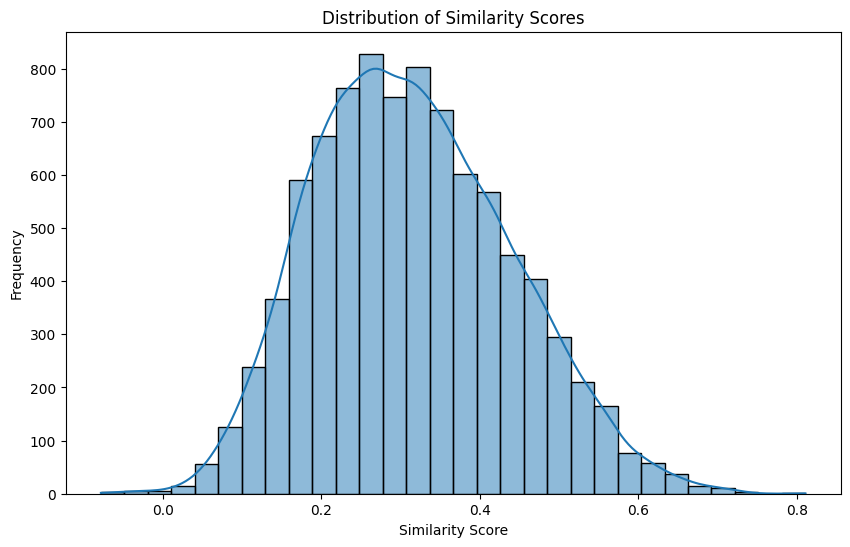

Visualization 1: The histogram above shows the distribution of similarity scores between courses and skill roles.
 - Total number of similarity scores: 8832
 - If most scores are on the right, courses generally align well with skill roles.
 - If most scores are on the left, the alignment may be weak.
Proportion of similarity scores above 0.5: 7.99%
 - Number of scores above 0.5: 706
 - This means that 706 out of 8832 course-skill pairings have a similarity score above 0.5.
 - This proportion indicates the percentage of course-skill pairings with a similarity score above 0.5, which is often considered a good indicator of relevance.
Mean Similarity: 0.32
Median Similarity: 0.31
Standard Deviation of Similarity: 0.12
 - The mean similarity score (average): 0.32
 - The median similarity score (middle value): 0.31
 - The standard deviation of similarity scores (variability): 0.12
 - A higher mean and median suggest better overall alignment, while the standard deviation indicates how consist

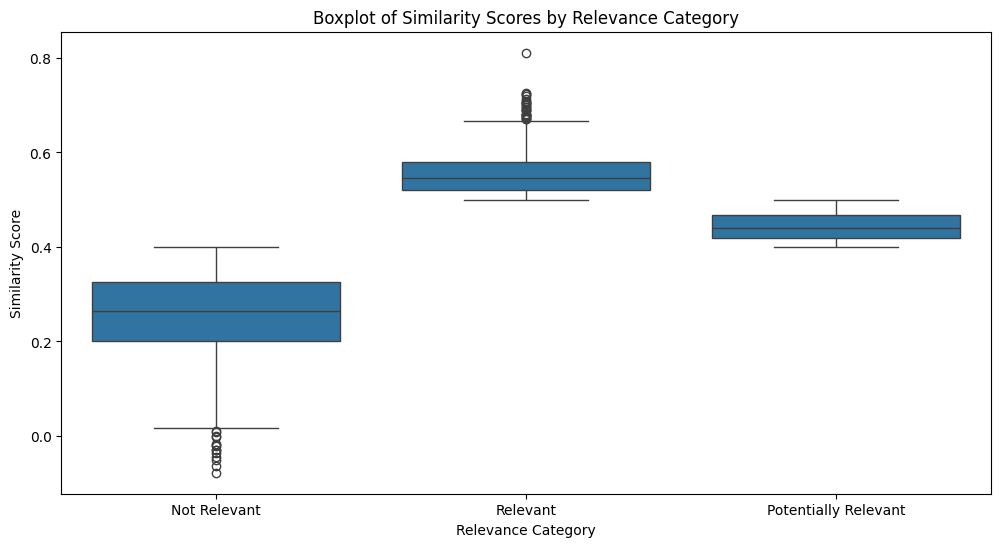

Visualization 2: The boxplot above categorizes similarity scores into 'Relevant', 'Potentially Relevant', and 'Not Relevant'.
 - Number of 'Relevant' category scores: 706
 - Number of 'Potentially Relevant' category scores: 1507
 - Number of 'Not Relevant' category scores: 6619
 - The median line in each box shows the typical score for that category.
 - A higher median for 'Relevant' indicates strong alignment, while wider boxes or many outliers suggest variability.


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming similarity_df contains the raw similarity scores

# 1. Visualize the distribution of similarity scores
plt.figure(figsize=(10, 6))
sns.histplot(similarity_df.values.flatten(), bins=30, kde=True)
plt.title('Distribution of Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.show()

# Key insights from the histogram
total_scores = len(similarity_df.values.flatten())
print("Visualization 1: The histogram above shows the distribution of similarity scores between courses and skill roles.")
print(f" - Total number of similarity scores: {total_scores}")
print(" - If most scores are on the right, courses generally align well with skill roles.")
print(" - If most scores are on the left, the alignment may be weak.")

# 2. Calculate the proportion of scores above a certain threshold (e.g., 0.5)
threshold = 0.5
num_above_threshold = (similarity_df.values.flatten() > threshold).sum()
proportion_above_threshold = num_above_threshold / total_scores
print(f"Proportion of similarity scores above {threshold}: {proportion_above_threshold:.2%}")
print(f" - Number of scores above {threshold}: {num_above_threshold}")
print(f" - This means that {num_above_threshold} out of {total_scores} course-skill pairings have a similarity score above 0.5.")
print(" - This proportion indicates the percentage of course-skill pairings with a similarity score above 0.5, which is often considered a good indicator of relevance.")

# 3. Summary statistics of the similarity scores
mean_similarity = similarity_df.values.flatten().mean()
median_similarity = np.median(similarity_df.values.flatten())
std_similarity = similarity_df.values.flatten().std()

print(f"Mean Similarity: {mean_similarity:.2f}")
print(f"Median Similarity: {median_similarity:.2f}")
print(f"Standard Deviation of Similarity: {std_similarity:.2f}")
print(f" - The mean similarity score (average): {mean_similarity:.2f}")
print(f" - The median similarity score (middle value): {median_similarity:.2f}")
print(f" - The standard deviation of similarity scores (variability): {std_similarity:.2f}")
print(" - A higher mean and median suggest better overall alignment, while the standard deviation indicates how consistent the alignments are.")

# 4. Boxplot for similarity scores by relevance category
# Flatten the similarity_df and categorized_df into lists
relevance_labels = categorized_df.iloc[:, 1:].values.flatten()
similarity_scores = similarity_df.values.flatten()

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Similarity Score': similarity_scores,
    'Relevance Category': relevance_labels
})

plt.figure(figsize=(12, 6))
sns.boxplot(x='Relevance Category', y='Similarity Score', data=plot_df)
plt.title('Boxplot of Similarity Scores by Relevance Category')
plt.show()

# Key insights from the boxplot
num_relevant = (plot_df['Relevance Category'] == 'Relevant').sum()
num_potentially_relevant = (plot_df['Relevance Category'] == 'Potentially Relevant').sum()
num_not_relevant = (plot_df['Relevance Category'] == 'Not Relevant').sum()

print("Visualization 2: The boxplot above categorizes similarity scores into 'Relevant', 'Potentially Relevant', and 'Not Relevant'.")
print(f" - Number of 'Relevant' category scores: {num_relevant}")
print(f" - Number of 'Potentially Relevant' category scores: {num_potentially_relevant}")
print(f" - Number of 'Not Relevant' category scores: {num_not_relevant}")
print(" - The median line in each box shows the typical score for that category.")
print(" - A higher median for 'Relevant' indicates strong alignment, while wider boxes or many outliers suggest variability.")


In [55]:
total_pairs = len(similarity_scores)
relevant_count = (plot_df['Relevance Category'] == 'Relevant').sum()
potentially_relevant_count = (plot_df['Relevance Category'] == 'Potentially Relevant').sum()
not_relevant_count = (plot_df['Relevance Category'] == 'Not Relevant').sum()

print(f"Total pairs: {total_pairs}")
print(f"Relevant pairs: {relevant_count} ({relevant_count/total_pairs:.2%})")
print(f"Potentially Relevant pairs: {potentially_relevant_count} ({potentially_relevant_count/total_pairs:.2%})")
print(f"Not Relevant pairs: {not_relevant_count} ({not_relevant_count/total_pairs:.2%})")


Total pairs: 8832
Relevant pairs: 706 (7.99%)
Potentially Relevant pairs: 1507 (17.06%)
Not Relevant pairs: 6619 (74.94%)


In [57]:
similarity_df

,Chief Information Security Officer (CISO),Cyber Incident Responder,"Cyber Legal, Policy & Compliance Officer",Cyber Threat Intelligence Specialist,Cybersecurity Architect,Cybersecurity Auditor,Cybersecurity Educator,Cybersecurity Implementer,Cybersecurity Researcher,Cybersecurity Risk Manager,Digital Forensics Investigator,Penetration Tester
0,0.073672,0.115591,0.242414,0.270443,0.151649,0.199463,0.207078,0.076814,0.235811,0.157722,0.309387,0.268777
1,0.278895,0.181991,0.338310,0.189011,0.218822,0.264855,0.281395,0.166735,0.352533,0.236447,0.228373,0.252970
2,0.395733,0.523761,0.496123,0.333389,0.460356,0.383698,0.414296,0.516623,0.423055,0.489318,0.295523,0.391506
3,0.141966,0.387301,0.130280,0.179790,0.244978,0.214070,0.130598,0.310197,0.116307,0.253714,0.237857,0.333814
4,0.309454,0.328974,0.171723,0.207956,0.211262,0.225245,0.188931,0.312468,0.054672,0.214068,0.224543,0.190163
...,...,...,...,...,...,...,...,...,...,...,...,...
731,0.240024,0.453078,0.255241,0.341226,0.238399,0.376272,0.254669,0.283759,0.302361,0.295803,0.558772,0.329583
732,0.437681,0.528837,0.485643,0.452763,0.396544,0.597109,0.321326,0.492635,0.425601,0.458856,0.560924,0.521047
733,0.378300,0.447356,0.453839,0.326381,0.473555,0.459801,0.316380,0.554654,0.336759,0.463632,0.352552,0.473844
734,0.500820,0.566724,0.413836,0.537351,0.374172,0.500437,0.400979,0.480078,0.327115,0.523819,0.504015,0.392004


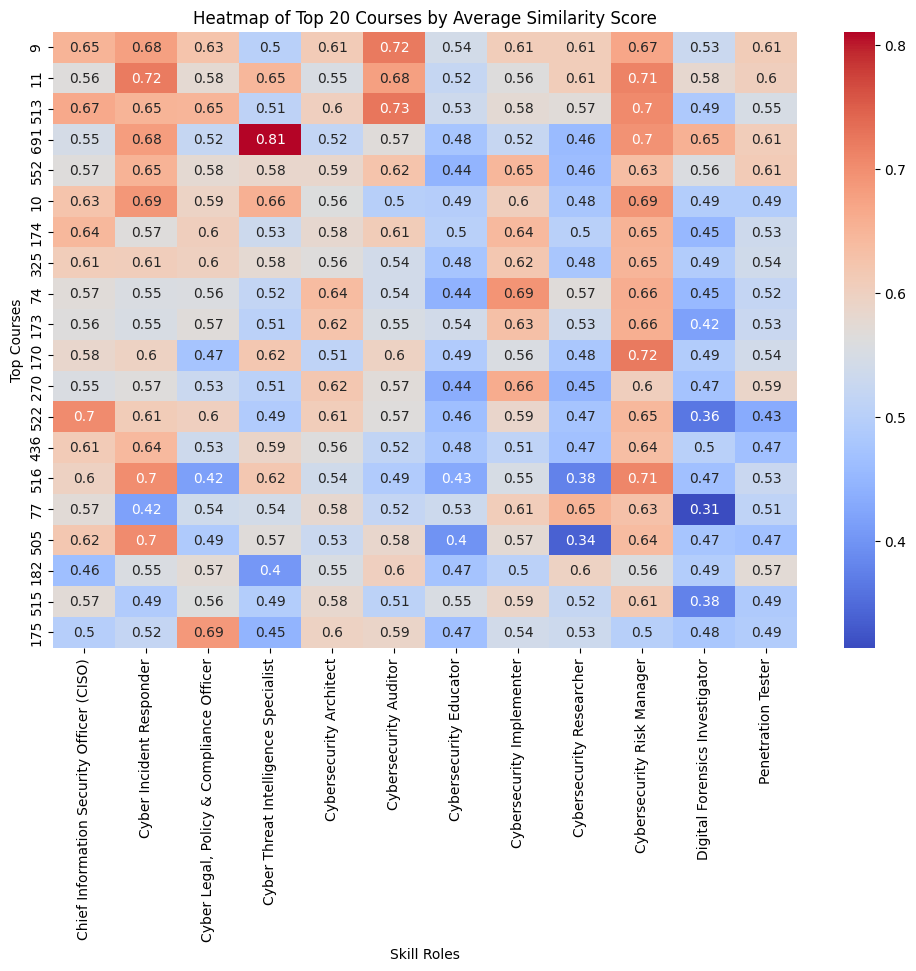

Top 20 Courses by Average Similarity Score:
Information Security Management Systems (ISMS): Average Similarity Score = 0.61
Cyber Resilience: Average Similarity Score = 0.61
Corporate governance, risk management and compliance: Average Similarity Score = 0.60
SMART PROTECTION AGAINST CYBER THREATS: Average Similarity Score = 0.59
Design and Development of Secure Systems: Average Similarity Score = 0.58
Cyber Warfare: Average Similarity Score = 0.57
Information Security Governance: Average Similarity Score = 0.57
Security governance and compliance: Average Similarity Score = 0.56
Cybersecurity of Networks: Average Similarity Score = 0.56
Cybersecurity and Critical Infrastructure Protection: Average Similarity Score = 0.56
Information Security Risk and Compliance Management: Average Similarity Score = 0.55
DEVSECOPS IN AUTONOMOUS SYSTEMS: Average Similarity Score = 0.55
IT Governance: Average Similarity Score = 0.55
Specialisation I: Average Similarity Score = 0.54
Critical Infrastructur

In [58]:
# 1. Add the "Course Title" column to the DataFrame
similarity_df['Course Title'] = course_titles

# 2. Identify the top 20 courses by their average similarity score
top_courses_with_scores = similarity_df.iloc[:, :-1].mean(axis=1).nlargest(20)  # Excluding the last column before adding 'Course Title'
top_courses = top_courses_with_scores.index

# 3. Create a heatmap for the top 20 courses
plt.figure(figsize=(12, 8))
sns.heatmap(similarity_df.loc[top_courses, similarity_df.columns[:-1]], annot=True, cmap='coolwarm')
plt.title('Heatmap of Top 20 Courses by Average Similarity Score')
plt.xlabel('Skill Roles')
plt.ylabel('Top Courses')
plt.show()

# 4. Print the top 20 courses with their average similarity scores using the "Course Title" column
print("Top 20 Courses by Average Similarity Score:")
for course in top_courses_with_scores.index:
    avg_score = top_courses_with_scores.loc[course]
    course_name = similarity_df.loc[course, 'Course Title']
    print(f"{course_name}: Average Similarity Score = {avg_score:.2f}")

# 5. Key insights from the heatmap
max_score = top_courses_with_scores.max()
min_score = top_courses_with_scores.min()

print("\nKey Insights from the Heatmap:")
print(f" - The top 20 courses were selected based on their average similarity scores, which range from {min_score:.2f} to {max_score:.2f}.")
print(f" - These courses show the strongest alignment with skill roles in your dataset.")
print(" - The color gradient in the heatmap provides a visual representation of these scores, with warmer colors indicating higher similarity.")
print(" - Annotated similarity scores within the heatmap cells allow for precise identification of how well each course aligns with each skill role.")
print(" - This heatmap helps in quickly identifying which courses are best designed to meet the needs of various skill roles.")